In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [5]:
folder = "/Users/jennaqasqas/python_decal_sp26/course_assignments/homework10"

file_names = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

all_data = []
all_headers = []


for file in file_names:
    file_path = f"{folder}/{file}"
    with fits.open(file_path) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        all_headers.append(header)
        all_data.append(data)

print("loaded", len(all_data), "files")

loaded 5 files


## 3.2 Plot Images

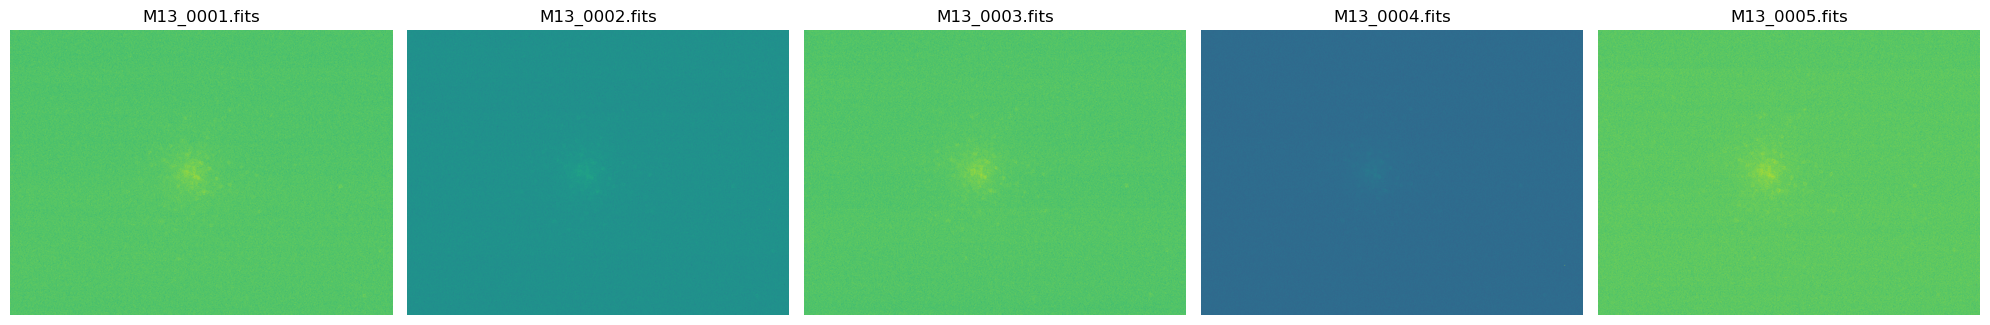

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    axes[i].imshow(all_data[i], origin="lower")
    axes[i].set_title(file_names[i])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

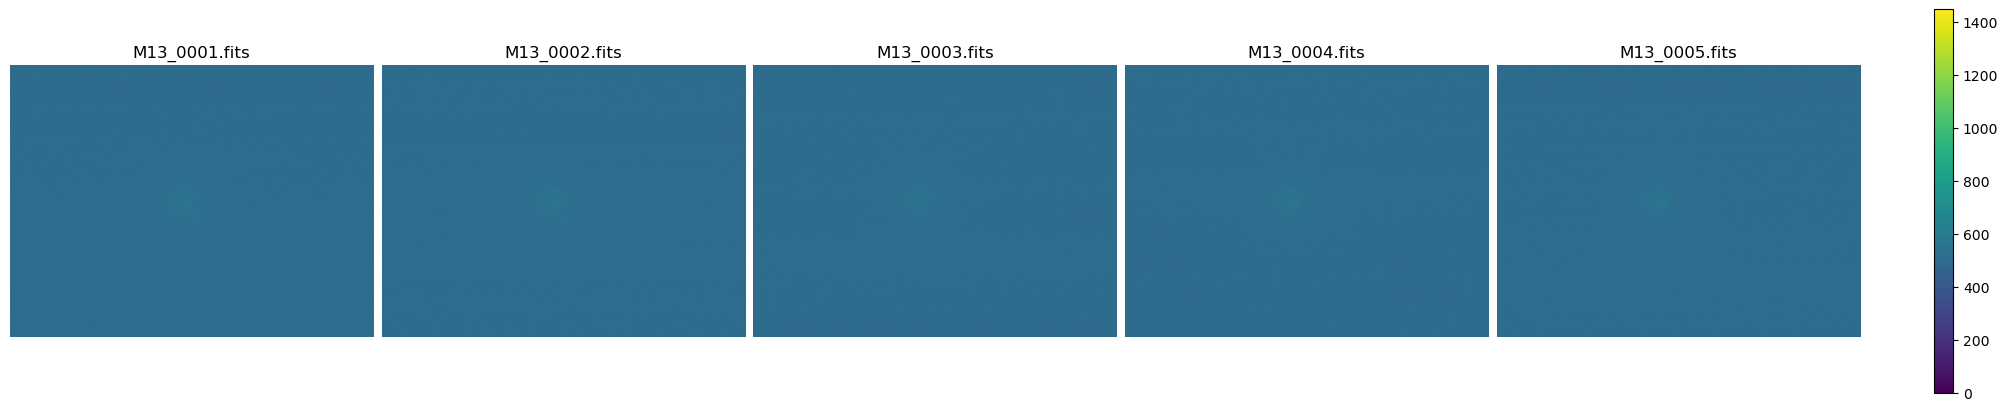

In [8]:
vmin = min(np.min(data) for data in all_data)
vmax = max(np.max(data) for data in all_data)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)

for i in range(5):
    im = axes[i].imshow(all_data[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(file_names[i])
    axes[i].axis("off")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
plt.show()

In the first set of images, each plot used a scale relative to its own data, making it difficult to compare the plots to each other. In the second set, all figures are plotted with the same color scale and so the brightness and contrast are easier to directly compare

## 3.3 Histograms

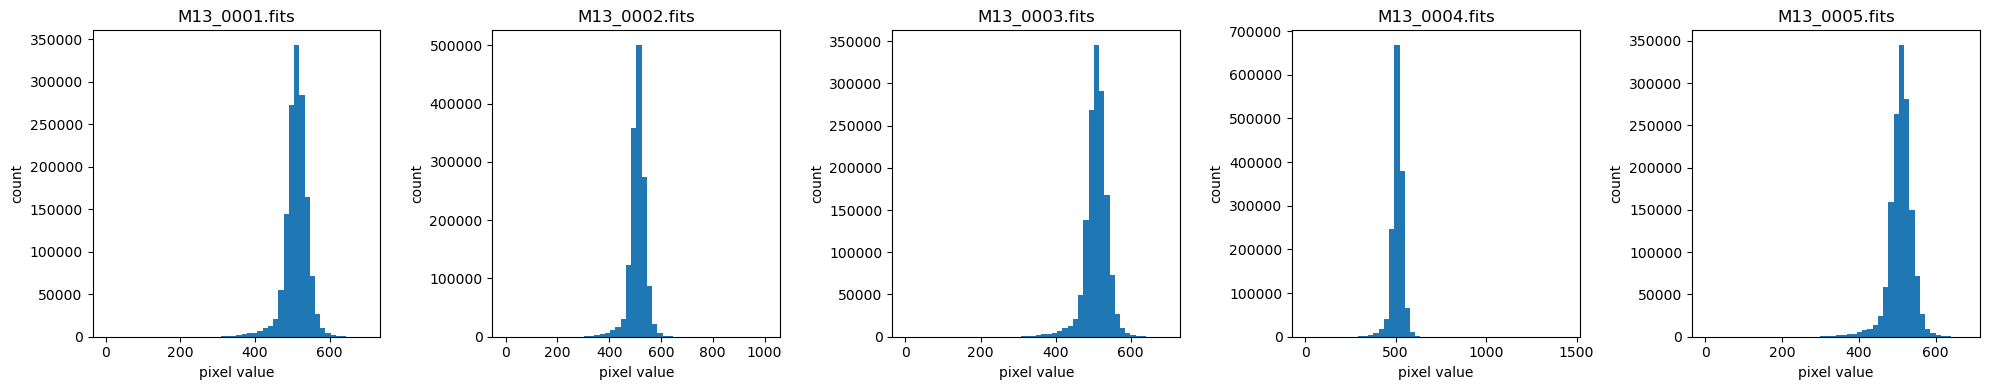

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    axes[i].hist(all_data[i].ravel(), bins=50)
    axes[i].set_title(file_names[i])
    axes[i].set_xlabel("pixel value")
    axes[i].set_ylabel("count")

plt.tight_layout()
plt.show()

a) the x-axis corresponds to the pixel value, and the y axis corresponds to the count or intensity of those set pixels.

b) bins=50 means the full range of pixel values is divided into 50 groups. The histogram counts how many pixels are in each group.

c) The data is centered around the background pixel intensity (largest peak)

d) The spread is the width of the main cluster of values around that peak. It tells us how much variance is in our dataset.

e) :

In [11]:
for i in range(5):
    mean_val = np.mean(all_data[i])
    median_val = np.median(all_data[i])
    print(f"{file_names[i]}: mean = {mean_val:.2f}, median = {median_val:.2f}")

M13_0001.fits: mean = 510.47, median = 512.00
M13_0002.fits: mean = 509.75, median = 511.00
M13_0003.fits: mean = 508.05, median = 510.00
M13_0004.fits: mean = 507.91, median = 509.00
M13_0005.fits: mean = 508.79, median = 510.00


## 3.4 Combine and Normalize

In [12]:
combined_image = np.median(all_data, axis=0)

combined_median = np.median(combined_image)
print("median pixel intensity of combined image:", combined_median)

median pixel intensity of combined image: 510.0


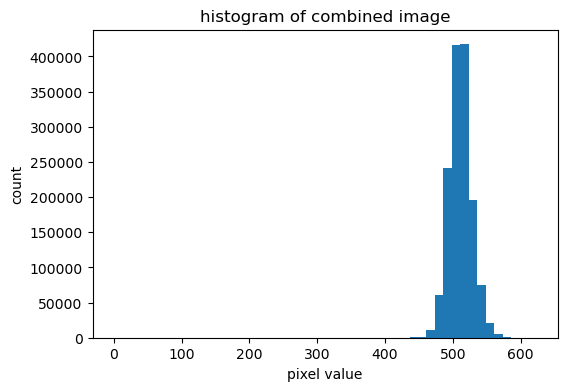

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("pixel value")
plt.ylabel("count")
plt.title("histogram of combined image")
plt.show()

difference = 100.0


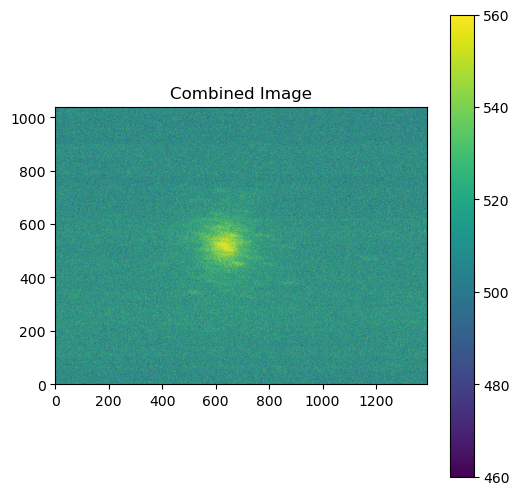

In [15]:
vmin = combined_median - 50
vmax = combined_median + 50
print("difference =", vmax - vmin)

plt.figure(figsize=(6, 6))
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image")
plt.show()